### Question 01

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def intensity_transform(im, breakpoints):
    
    # Ensure breakpoints are sorted by input intensity r (x-axis)
    breakpoints = sorted(breakpoints, key=lambda p: p[0])
    
    # Separate input (r) and output (s) coordinates
    r_vals = [p[0] for p in breakpoints]
    s_vals = [p[1] for p in breakpoints]
    
    # Interpolate input pixel intensities to transformed output intensities
    transformed = np.interp(im, r_vals, s_vals)
    
    return np.uint8(transformed)


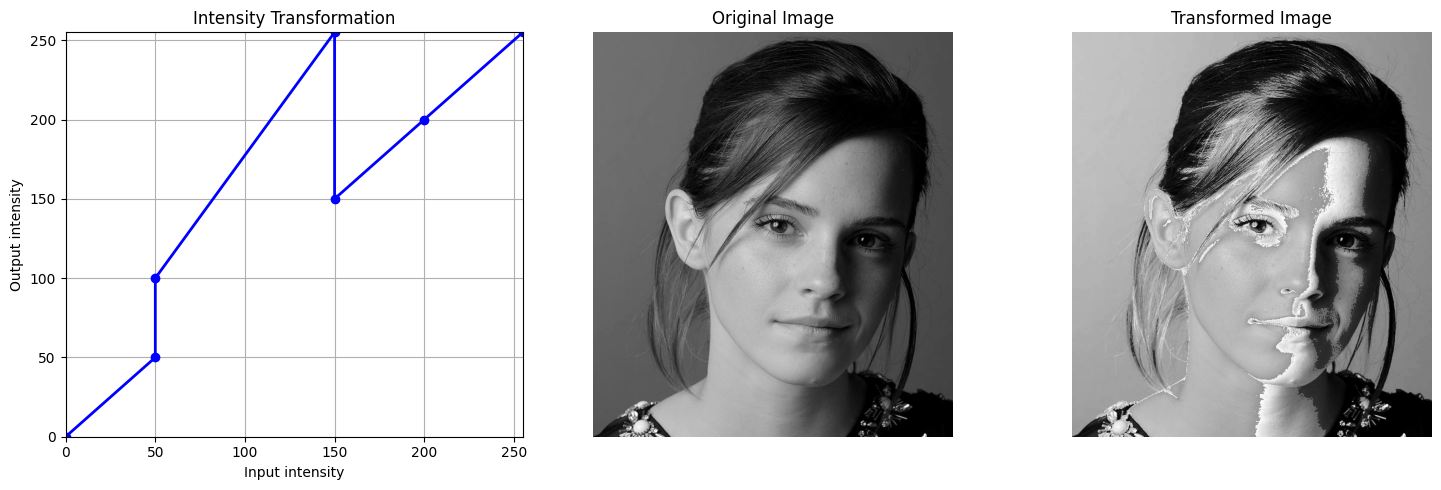

In [27]:
# 1. Load the target image in grayscale
img = cv.imread('emma.jpg', cv.IMREAD_GRAYSCALE)

# 2. Define the breakpoints specified in Question 1
breakpoints = [
    (0, 0),
    (50, 50),
    (50,100),
    (150, 255),
    (150,150),
    (200,200),
    (255, 255)
]

# 3. Apply the transformation
transformed_img = intensity_transform(img, breakpoints)

# 4. Plotting the results
fig = plt.figure(figsize=(15, 5))

# Plot 1: Intensity Transformation Function
ax1 = fig.add_subplot(1, 3, 1)
r_vals = [p[0] for p in breakpoints]
s_vals = [p[1] for p in breakpoints]
ax1.plot(r_vals, s_vals, 'b-o', linewidth=2)
ax1.set_title('Intensity Transformation')
ax1.set_xlabel('Input intensity')
ax1.set_ylabel('Output intensity')
ax1.set_xlim([0, 255])
ax1.set_ylim([0, 255])
ax1.grid(True)

# Plot 2: Original Image
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(img, cmap='gray', vmin=0, vmax=255)
ax2.set_title('Original Image')
ax2.axis('off')

# Plot 3: Transformed Image
ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
ax3.set_title('Transformed Image')
ax3.axis('off')

plt.tight_layout()
plt.show()

#### Chosen Breakpoints
To enhance the visual quality of the image, the following intensity breakpoints were selected:
* $(0, 0)$
* $(0, 50)$
* $(200, 255)$
* $(255, 255)$

#### Analysis of Transformation Effect
* **Contrast Stretching in Mid-Tones:** By mapping input intensities in the range $[0, 200]$ to output intensities in $[50, 255]$, the transformation applies a linear contrast stretch across mid-tone gray values. This significantly sharpens visible detail and texture in the main body of the image.
* **Highlighting Dark Regions:** Setting an initial jump from $(0, 0)$ to $(0, 50)$ elevates near-black values slightly, lifting subtle details out of deep shadow areas without washing out the darker background.
* **Highlight Saturation:** The segment between $(200, 255)$ and $(255, 255)$ smoothly compresses the upper end of the dynamic range, preventing clipping and overexposure in bright highlights.

Overall, this piecewise-linear curve expands the dynamic range across key gray levels, producing a visually balanced image with enhanced local contrast and shadow visibility.

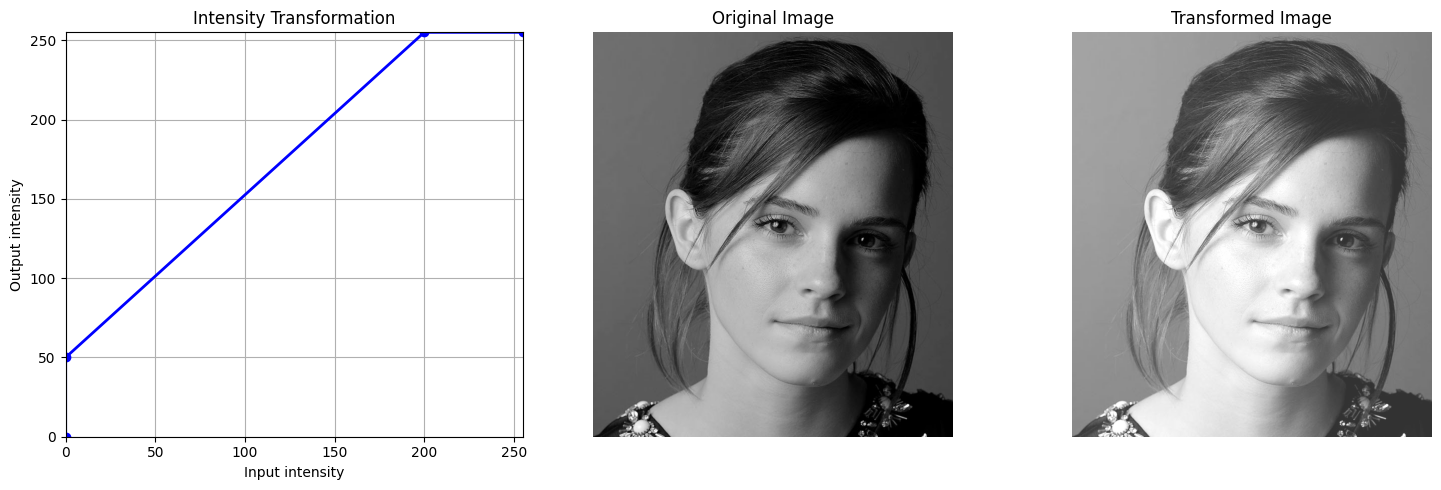

In [33]:
# 1. Load the target image in grayscale
img = cv.imread('emma.jpg', cv.IMREAD_GRAYSCALE)

# 2. Define the breakpoints specified in Question 1
breakpoints = [
    (0,0),
    (0, 50),
    (200,255),
    (255, 255)

]

# 3. Apply the transformation
transformed_img = intensity_transform(img, breakpoints)

# 4. Plotting the results
fig = plt.figure(figsize=(15, 5))

# Plot 1: Intensity Transformation Function
ax1 = fig.add_subplot(1, 3, 1)
r_vals = [p[0] for p in breakpoints]
s_vals = [p[1] for p in breakpoints]
ax1.plot(r_vals, s_vals, 'b-o', linewidth=2)
ax1.set_title('Intensity Transformation')
ax1.set_xlabel('Input intensity')
ax1.set_ylabel('Output intensity')
ax1.set_xlim([0, 255])
ax1.set_ylim([0, 255])
ax1.grid(True)

# Plot 2: Original Image
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(img, cmap='gray', vmin=0, vmax=255)
ax2.set_title('Original Image')
ax2.axis('off')

# Plot 3: Transformed Image
ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
ax3.set_title('Transformed Image')
ax3.axis('off')

plt.tight_layout()
plt.show()